# HW1  Try out gradient descent

## Due Friday April 24th, 2020

1) [5 points] Calculate the derivative of following cost function and write it down:

$g(w) = \frac{1}{50}\left(w^4 + w^2 + 10w - 50 \right)$

### Answer
$\frac{\partial}{\partial w}g(w) = \frac{1}{25}\left(2w^3 + w + 5\right)$

2) [25 points] Implement the gradient descent function as discussed in class using the gradient derived in the last problem. The function should return the cost history for each step. Use the code template below:


In [58]:
#gradient descent function
#inputs: alpha (learning rate parameter), max_its (maximum number of iterations), w (initialization)
def gradient_descent(alpha,max_its,w0):
    ##Your code here
    cost_history = []   # list to hold cost at every iteration
    wk_1 = w0           # intial weight
    for i in range(max_its):
        cost = (wk_1**4 + wk_1**2 + 10*wk_1 - 50)/50 # compute cost for each weight
        cost_history.append(cost)  # build cost history
        grad = (2*wk_1**3 + wk_1 + 5)/25 # hand calculated gradient function
        wk = wk_1 - alpha*grad           
        wk_1 = wk    # update next weight
    return cost_history

3) [10 points] Run the gradient_descent function you implemented three times, with the following parameters. Generate a single plot showing the cost as a function of step number for all three runs (combine all three runs into a single plot). If you are not familiar with plotting in python, here is the docs for matplotlib:(https://matplotlib.org/3.2.1/api/_as_gen/matplotlib.pyplot.plot.html#matplotlib.pyplot.plot). 


$w^0$ = 2.0
max_its = 1000

# first run
alpha = 1
# second run
alpha = 0.1
# third run
alpha = 0.01


In [59]:
max_its = 1000
w0 = 2.0
first_run = gradient_descent(1,max_its,w0)
second_run = gradient_descent(0.1,max_its,w0)
third_run = gradient_descent(0.01,max_its,w0)

Text(0.5, 1.0, 'Cost as a function of steps')

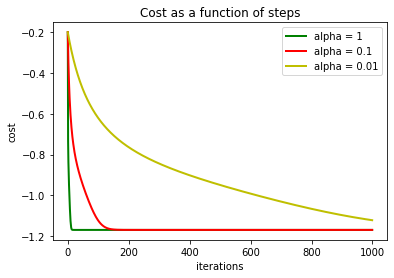

In [60]:
import matplotlib.pyplot as plt
# To keep your plots embedded
%matplotlib inline 
i = [x for x in range(1000)]
plt.plot(i,first_run, 'g-', label='alpha = 1', linewidth=2)
plt.plot(i,second_run, 'r-', label='alpha = 0.1', linewidth=2)
plt.plot(i,third_run, 'y-', label='alpha = 0.01', linewidth=2)
##Your code here
plt.legend()
plt.xlabel('iterations')
plt.ylabel('cost')
plt.title('Cost as a function of steps')

For the next few problems we will be comparing fix length and diminishing learning parameters

Take the following cost function:
\begin{equation}
g(w) = \left \vert w \right \vert
\end{equation}

4) [5 points] Is this function convex? If no, why not? If yes, where is its global minimum?

### Answer
$Yes$ the function is convex

It has a $global$ minimum at w = 0

5) [5 points] What is the derivative of the cost function? 

### Answer
for w < 0,
$\frac{\partial}{\partial w}g(w) = -1$

for w > 0,
$\frac{\partial}{\partial w}g(w) = 1$

for w = 0,
$\frac{\partial}{\partial w}g(w) = undefined$

6) [20 points] Rewrite the gradient descent function from question 2 such that it takes the cost funciton g as input and uses the autograd library to calculate the gradient. The function should return the weight and cost history for each step. Use the code template below.

autograd is a python package for automatic differentiation. Here is a tutorial on it: (http://www.cs.toronto.edu/~rgrosse/courses/csc321_2017/tutorials/tut4.pdf

Note that in Python you can pass functions around like any other variables. That is why you can pass the cost function g to the gradient_descent function. Look at example below:


In [61]:
##Example of passing functions as variables
f1 = lambda p: p**2  #Function that will be passed around

def f2(function,p):
    return function(p)

print(f2(f1,3))  ##Calling f2 with f1 as a parameter
print(f1(2))

9
4


In [62]:
from autograd import grad 

#gradient descent function
#inputs: g (cost function), alpha (learning rate parameter), max_its (maximum number of iterations), w (initialization)

def gradient_descent(g,alpha,max_its,w0):
    gradient = grad(g)   ## This is how you use the autograd library to find the gradient of a function  
    ##Your code here
    wk_1 = w0
    weight_history = []
    cost_history = []
    for i in range (max_its):
        cost_history.append(g(wk_1)) # compute and append cost to history
        weight_history.append(wk_1)  # build weight history
        wk = wk_1 - alpha*gradient(wk_1)
        wk_1 = wk
    return weight_history,cost_history

7) [10 points] Make a run of max_its=20 steps of gradient descent with initialization at the point $w^0 = 1.75$, and a fixed learning rate of $\alpha = 0.5$. Using the cost and wiehgt history, plot the cost as a function of the weight for each step (cost on y-axis, weight on x-axis)

In [63]:
cost_function = lambda w: abs(w)
history = gradient_descent(cost_function,0.5,20,1.75)

Text(0.5, 1.0, 'Cost as a function of weight')

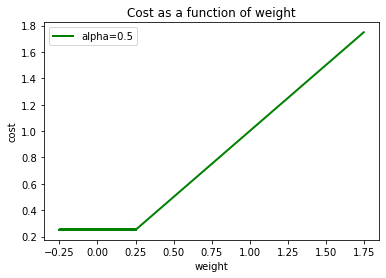

In [64]:
plt.plot(history[0],history[1], 'g-', label='alpha=0.5', linewidth=2)
plt.legend()
plt.xlabel('weight')
plt.ylabel('cost')
plt.title('Cost as a function of weight')


8) [15 points] Make a run of max_its=20 steps of gradient descent with initialization at the point $w^0 = 1.75$, using the diminishing rule $\alpha = \frac{1}{k}$ (for this you have to modify the gradient_descent function slightly. Use the code template below. Using the cost and wiehgt history, plot the cost as a function of the weight for each step (cost on y-axis, weight on x-axis)

In [65]:
from autograd import grad 

#gradient descent function
#inputs: g (cost function), alpha (learning rate parameter), max_its (maximum number of iterations), w (initialization)
def gradient_descent(g,alpha,max_its,w0):
    gradient = grad(g)   ## This is how you use the autograd library to find the gradient of a function 
    ##Your code here
    wk_1 = w0
    weight_history = []
    cost_history = []
    if alpha=='diminishing':
        for k in range(1,max_its + 1):
            alpha = 1/k
            cost_history.append(g(wk_1))
            weight_history.append(wk_1)
            wk = wk_1 - alpha*gradient(wk_1)
            wk_1 = wk
    else:
        for i in range(max_its):
            cost_history.append(g(wk_1))
            weight_history.append(wk_1)
            wk = wk_1 - alpha*gradient(wk_1)
            wk_1 = wk
    return weight_history,cost_history

In [66]:
cost_function = lambda w: abs(w)
history_diminishing = gradient_descent(cost_function,'diminishing',20,1.75)

Text(0.5, 1.0, 'Cost as a function of weight')

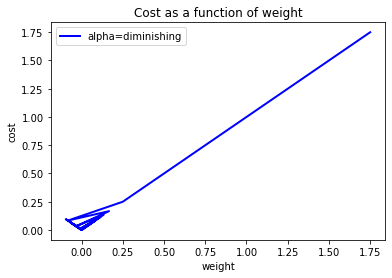

In [67]:
import matplotlib.pyplot as plt
# To keep your plots embedded 
plt.plot(history_diminishing[0],history_diminishing[1], 'b-', label='alpha=diminishing', linewidth=2)
plt.legend()
plt.xlabel('weight')
plt.ylabel('cost')
plt.title('Cost as a function of weight')

9) [10 points]  Generate a single plot showing the cost as a function of step number for both runs (combine all  runs into a single plot). Which approach works better? Why ?

Text(0.5, 1.0, 'Cost as a function of steps')

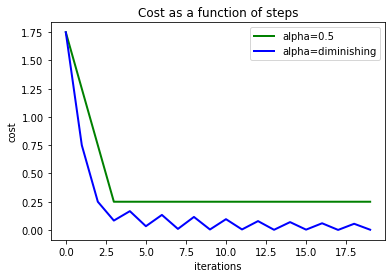

In [68]:
num_its = 20
itera = [x for x in range(num_its)]
plt.plot(itera,history[1], 'g-', label='alpha=0.5', linewidth=2)
plt.plot(itera,history_diminishing[1], 'b-', label='alpha=diminishing', linewidth=2)
plt.legend()
plt.xlabel('iterations')
plt.ylabel('cost')
plt.title('Cost as a function of steps')

### Answer
The $diminishing$ $alpha$ approach works better . Although it oscillates, we can see that it will $converge$ to the $global$ $minimum$,0, with more iterations.

We will now look at the oscilating behavior of gradient descent. 

Take the following cost function:
$g(w) = w_0^2 + w_1^2 + 2\sin(1.5 (w_0 + w_1)) +2$

Note that this cost function has two parameters.

10) [5 points] Make sure your gradient descent function from problem 6 can handle cost functions with more than one parameter. You may need to rewrite it if you were not careful (i.e., did not use numpy matrices). Use the code template below (if your function from problem 6 is good, you can just copy and paste it here)

In [69]:
from autograd import grad 

#gradient descent function
#inputs: g (cost function), alpha (learning rate parameter), max_its (maximum number of iterations), w (initialization)
def gradient_descent(g,alpha,max_its,w0):
    gradient = grad(g)   ## This is how you use the autograd library to find the gradient of a function  
    ##Your code here
    wk_1 = w0
    weight_history = []
    cost_history = []
    wk = [0]*len(w0)
    for k in range(max_its):
        cost_history.append(g(wk_1))
        weight_history.append(wk_1)
        # simultaneosly update
        for i in range(len(w0)):
            wk[i] = wk_1[i] - alpha*gradient(wk_1)[i]
        wk_1 = wk
    return weight_history,cost_history

11) [10 points] Run the gradient_descent function with the cost function above three times with the following parameters. Generate a single plot showing the cost as a function of step number for all three runs (combine all three runs into a single plot). Use the code template below. Which alpha leads to an oscillating behavior?

$w^0$ = [3.0,3.0]
max_its = 10

# first run
alpha = 0.01
# second run
alpha = 0.1
# third run
alpha = 1



Text(0.5, 1.0, 'Cost as a function of steps')

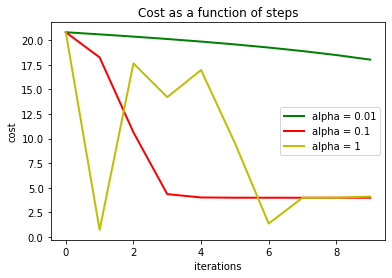

In [70]:
import autograd.numpy as np
g = lambda w: w[0]**2 + w[1]**2 + 2*np.sin(1.5*(w[0] + w[1])) + 2
#Your code here
w0 = [3.0,3.0]
max_its = 10
x = [x for x in range(10)]
first_run = gradient_descent(g,0.01,max_its,w0)
second_run = gradient_descent(g,0.1,max_its,w0)
third_run = gradient_descent(g,1,max_its,w0)
plt.plot(x,first_run[1], 'g-', label='alpha = 0.01', linewidth=2)
plt.plot(x,second_run[1], 'r-', label='alpha = 0.1', linewidth=2)
plt.plot(x,third_run[1], 'y-', label='alpha = 1', linewidth=2)
plt.legend()
plt.xlabel('iterations')
plt.ylabel('cost')
plt.title('Cost as a function of steps')

### Answer
$alpha$ = 1 leads to an $oscillating$ $behaviour$

12) [15 points] This problem is about learning to tune fixed step length for gradient descent. Here, you are given a cost function:
$g(w) = 2w_0^2 + w_1^2 +4w_2^2$ 

Assume your $w^0$= [5,5,5] and your max_iter = 100

Use your latest gradient descent function with a fixed learning rate. Play around with at least 5 different values of alpha (using your intuition). Generate a single plot of the cost as a function of the number of iterations. Which value of alpha seems to converge the fastest?

Not that your grade will not depend on how well you do, as long as you try at least 5 different values for alpha. and plot them.

Text(0.5, 1.0, 'Cost as a function of steps')

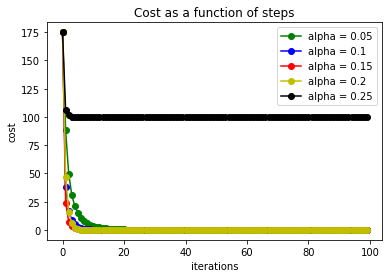

In [71]:
g = lambda w: 2*w[0]**2 + w[1]**2 + 4*w[2]**2
w0 = [5.0,5.0,5.0]
max_iterations = 100
x = [x for x in range(max_iterations)]

run1 = gradient_descent(g,0.05,max_iterations,w0)
plt.plot(x,run1[1],'go-',label = 'alpha = 0.05')

run2 = gradient_descent(g,0.1,max_iterations,w0)
plt.plot(x,run2[1],'bo-',label = 'alpha = 0.1')

run3 = gradient_descent(g,0.15,max_iterations,w0)
plt.plot(x,run3[1],'ro-',label = 'alpha = 0.15')

run4 = gradient_descent(g,0.2,max_iterations,w0)
plt.plot(x,run4[1],'yo-',label = 'alpha = 0.2')

run5 = gradient_descent(g,0.25,max_iterations,w0)
plt.plot(x,run5[1],'ko-',label = 'alpha = 0.25')

plt.legend()
plt.xlabel('iterations')
plt.ylabel('cost')
plt.title('Cost as a function of steps')

### Answer
$alpha$ = 0.15 seems to converge the fastest